# 📊 Projeto de Análise

**Objetivo:** Definir como a hCaptcha deve se posicionar no mercado europeu com base em leads B2B de tecnologia.

**Data:** 2026-04-23

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR if (CURRENT_DIR / 'data').exists() else CURRENT_DIR.parent
DATA_ROOT = PROJECT_ROOT / 'data'
RAW_CSV = DATA_ROOT / 'raw' / 'hcaptcha_europe_raw.csv'
PROCESSED_DIR = DATA_ROOT / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT / 'scripts'))

from hcaptcha_pipeline import (
    build_company_size_dimension,
    build_country_priority_dimension,
    build_data_quality_summary,
    build_role_category_dimension,
    export_processed_outputs,
    is_european_country,
    load_raw_dataset,
    transform_dataset,
)

print('Ambiente pronto! ✅')
print(f'Projeto: {PROJECT_ROOT}')
print(f'Fonte raw: {RAW_CSV}')

Ambiente pronto! ✅
Projeto: /home/lucasguldem/dev/data-science/isabellysto-data-analytics
Fonte raw: /home/lucasguldem/dev/data-science/isabellysto-data-analytics/data/raw/hcaptcha_europe_raw.csv


## 1. Carga, Tratamento e Exportação

O pipeline usa `País da empresa` como fonte geográfica de verdade, remove duplicados por `E-mail + Nome da empresa`, normaliza cargos e bucketiza `Tamanho da empresa`.

In [2]:
raw_df = load_raw_dataset(RAW_CSV)
clean_df = transform_dataset(raw_df)
quality_df = build_data_quality_summary(raw_df, clean_df)
role_dim = build_role_category_dimension(clean_df)
size_dim = build_company_size_dimension(clean_df)
country_dim = build_country_priority_dimension(clean_df)
exported_files = export_processed_outputs(clean_df, PROCESSED_DIR)

summary_df = pd.DataFrame(
    [
        {'metric': 'raw_rows', 'value': len(raw_df)},
        {'metric': 'clean_rows', 'value': len(clean_df)},
        {'metric': 'unique_companies', 'value': clean_df['company_name'].nunique()},
        {'metric': 'countries_in_scope', 'value': clean_df['company_country'].nunique()},
        {'metric': 'cross_border_contacts', 'value': int(clean_df['contact_company_country_mismatch'].eq(True).sum())},
    ]
)

display(summary_df)
display(quality_df)
display(country_dim.head(10))
display(pd.DataFrame({'artifact': list(exported_files.keys()), 'path': [str(path) for path in exported_files.values()]}))

,metric,value
0,raw_rows,1027
1,clean_rows,882
2,unique_companies,748
3,countries_in_scope,13
4,cross_border_contacts,89


,metric,value
0,raw_rows,1027
1,raw_duplicate_rows,203
2,clean_rows,882
3,european_rows,882
4,cross_border_contact_rows,89


,company_country,lead_count,company_count,executive_share,compliance_share,mismatch_share,country_rank,priority_tier,messaging_angle,strategic_recommendation
0,Germany,277,254,0.69,0.18,0.05,1,Tier 1,Privacy-first and GDPR-safe alternative to reC...,Target Germany with privacy-first and gdpr-saf...
1,United Kingdom,174,138,0.34,0.59,0.18,2,Tier 1,Developer efficiency and scalable anti-bot per...,Target United Kingdom with developer efficienc...
2,France,166,128,0.17,0.70,0.08,3,Tier 1,Privacy-first and GDPR-safe alternative to reC...,Target France with privacy-first and gdpr-safe...
3,Spain,101,82,0.31,0.10,0.10,4,Tier 1,Balanced anti-bot performance with compliance-...,Target Spain with balanced anti-bot performanc...
4,Portugal,62,58,0.16,0.00,0.10,5,Tier 1,Balanced anti-bot performance with compliance-...,Target Portugal with balanced anti-bot perform...
5,Poland,41,32,0.41,0.46,0.02,6,Tier 2,Balanced anti-bot performance with compliance-...,Target Poland with balanced anti-bot performan...
6,Belgium,21,20,0.33,0.52,0.19,7,Tier 2,Privacy-first and GDPR-safe alternative to reC...,Target Belgium with privacy-first and gdpr-saf...
7,Ireland,16,16,0.50,0.44,0.19,8,Tier 2,Developer efficiency and scalable anti-bot per...,Target Ireland with developer efficiency and s...
8,Lithuania,15,13,0.47,0.40,0.13,9,Tier 2,Developer efficiency and scalable anti-bot per...,Target Lithuania with developer efficiency and...
9,Estonia,6,5,0.67,0.33,0.17,10,Tier 2,Developer efficiency and scalable anti-bot per...,Target Estonia with developer efficiency and s...


,artifact,path
0,gold,/home/lucasguldem/dev/data-science/isabellysto...
1,role_dim,/home/lucasguldem/dev/data-science/isabellysto...
2,size_dim,/home/lucasguldem/dev/data-science/isabellysto...
3,country_dim,/home/lucasguldem/dev/data-science/isabellysto...


## 2. Auditoria da Qualidade dos Dados

Antes da análise estratégica, vale medir os principais ruídos de origem: duplicidade, vazamento geográfico e formatações atípicas de porte empresarial.

In [3]:
duplicate_rows = raw_df[raw_df.duplicated(subset=['E-mail', 'Nome da empresa'], keep=False)].copy()
country_leakage = raw_df[
    raw_df['País da empresa'].notna()
    & ~raw_df['País da empresa'].map(is_european_country)
].copy()
standard_sizes = {'1-10', '11-50', '51-200', '201-500', '501-1000', '1001-5000', '5001-10000', '10001+', 'Self'}
size_anomalies = raw_df[
    raw_df['Tamanho da empresa'].notna()
    & ~raw_df['Tamanho da empresa'].isin(standard_sizes)
][['Nome da empresa', 'Tamanho da empresa', 'Classificação']].drop_duplicates()

display(raw_df['Status do e-mail'].fillna('(vazio)').value_counts().rename_axis('email_status').reset_index(name='rows'))
display(raw_df['País da empresa'].fillna('(vazio)').value_counts().head(15).rename_axis('company_country').reset_index(name='rows'))
display(size_anomalies)
display(duplicate_rows[['E-mail', 'Nome da empresa', 'Status do e-mail', 'Cargo', 'País da empresa']].head(20))
display(country_leakage['País da empresa'].value_counts().rename_axis('company_country').reset_index(name='rows'))

,email_status,rows
0,valid,535
1,unknown,278
2,not valid,214


,company_country,rows
0,Germany,318
1,United Kingdom,189
2,France,183
3,Spain,119
4,Portugal,67
5,Poland,48
6,Belgium,22
7,Lithuania,21
8,Ireland,17
9,(vazio),10


,Nome da empresa,Tamanho da empresa,Classificação
8,Art2Trading,"46.296,00",Fora da faixa


,E-mail,Nome da empresa,Status do e-mail,Cargo,País da empresa
11,alireza.rezvani@lindera.de,Lindera,valid,Chief Technology Officer (CTO),Germany
19,lplaton@aquiladata.fr,Aquila Data Enabler,valid,Data Manager,France
20,lplaton@aquiladata.fr,Aquila Data Enabler,valid,Data Team Lead,France
23,richard@spendesk.com,Spendesk,valid,Chief Product and Technology Officer (CPTO),France
24,richard@spendesk.com,Spendesk,valid,Chief Technology Officer (CTO),France
25,jgracia@etiqmedia.com,ETIQMEDIA SOLUCIONES AUDIOVISUALES SL,valid,Co-founder of ETIQMEDIA,Spain
26,jgracia@etiqmedia.com,ETIQMEDIA SOLUCIONES AUDIOVISUALES SL,valid,CTO. Chief Technology Officer,Spain
27,agne.navikiene@tglab.com,TGLAB,not valid,Compliance Manager,Lithuania
28,agne.navikiene@tglab.com,TGLAB,not valid,Head of Customer Services,Lithuania
30,lluis.vegas@between.tech,Between Technology,valid,Head of IT,Spain


,company_country,rows
0,Brazil,8
1,United States,6
2,Mexico,3
3,Afghanistan,2
4,Australia,1
5,Singapore,1
6,United Arab Emirates,1
7,Japan,1


## 3. Mercado Prioritário na Europa

O foco principal é identificar onde existe massa crítica de leads e empresas com narrativa forte para o posicionamento da hCaptcha.

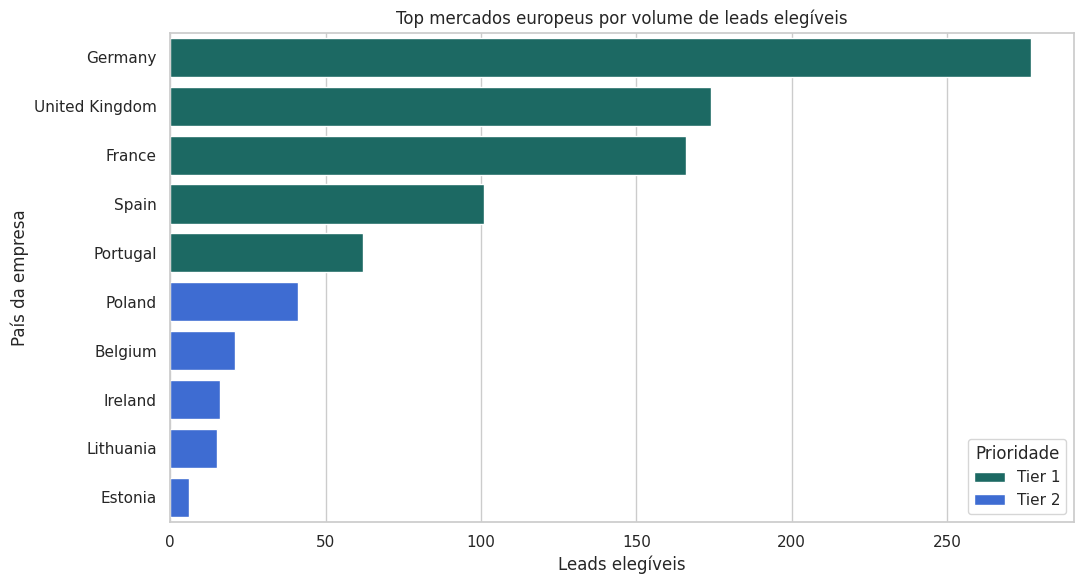

,company_country,lead_count,company_count,priority_tier,messaging_angle
0,Germany,277,254,Tier 1,Privacy-first and GDPR-safe alternative to reC...
1,United Kingdom,174,138,Tier 1,Developer efficiency and scalable anti-bot per...
2,France,166,128,Tier 1,Privacy-first and GDPR-safe alternative to reC...
3,Spain,101,82,Tier 1,Balanced anti-bot performance with compliance-...
4,Portugal,62,58,Tier 1,Balanced anti-bot performance with compliance-...
5,Poland,41,32,Tier 2,Balanced anti-bot performance with compliance-...
6,Belgium,21,20,Tier 2,Privacy-first and GDPR-safe alternative to reC...
7,Ireland,16,16,Tier 2,Developer efficiency and scalable anti-bot per...
8,Lithuania,15,13,Tier 2,Developer efficiency and scalable anti-bot per...
9,Estonia,6,5,Tier 2,Developer efficiency and scalable anti-bot per...


Figura salva em: /home/lucasguldem/dev/data-science/isabellysto-data-analytics/reports/figures/01_market_overview_top_countries.png


In [4]:
top_countries = country_dim.head(10).copy()
palette = {'Tier 1': '#0f766e', 'Tier 2': '#2563eb', 'Tier 3': '#94a3b8'}

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=top_countries,
    x='lead_count',
    y='company_country',
    hue='priority_tier',
    dodge=False,
    palette=palette,
    ax=ax,
)
ax.set_title('Top mercados europeus por volume de leads elegíveis')
ax.set_xlabel('Leads elegíveis')
ax.set_ylabel('País da empresa')
ax.legend(title='Prioridade', loc='lower right')
plt.tight_layout()
market_figure = FIGURES_DIR / '01_market_overview_top_countries.png'
plt.savefig(market_figure, dpi=150, bbox_inches='tight')
plt.show()

display(top_countries[['company_country', 'lead_count', 'company_count', 'priority_tier', 'messaging_angle']])
print(f'Figura salva em: {market_figure}')

## 4. ICP e Personas

A combinação entre `Role Category` e `Company Size Segment` mostra onde a abordagem comercial deve mudar de narrativa.

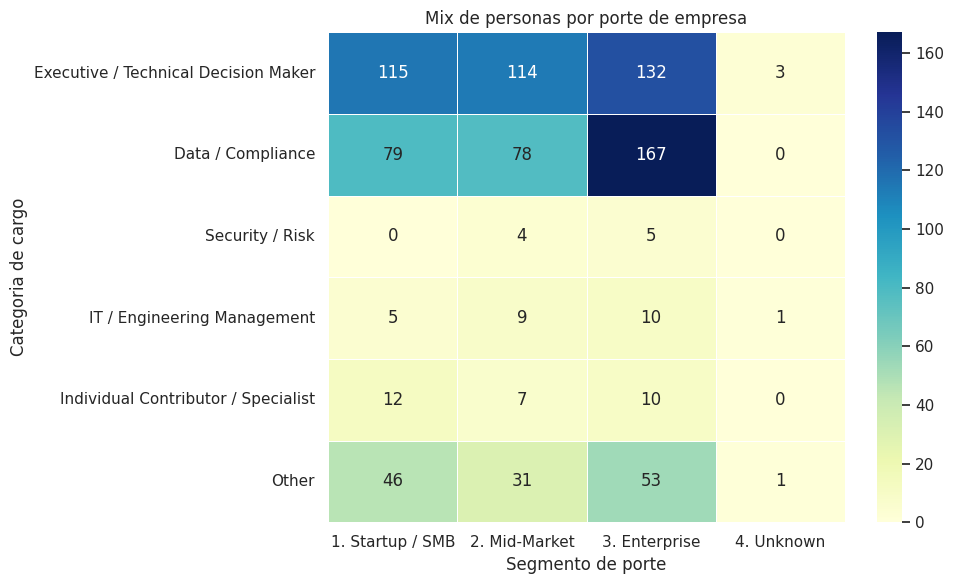

,role_category,lead_count,company_count,lead_share
0,Executive / Technical Decision Maker,364,346,0.41
1,Data / Compliance,324,253,0.37
2,Other,131,118,0.15
3,Individual Contributor / Specialist,29,29,0.03
4,IT / Engineering Management,25,21,0.03
5,Security / Risk,9,8,0.01


,company_size_segment,lead_count,company_count
0,3. Enterprise,377,293
1,1. Startup / SMB,257,237
2,2. Mid-Market,243,214
3,4. Unknown,5,5


,company_industry,lead_count
0,Information Technology & Services,377
1,Computer Software,283
2,Internet,15
3,Public Relations & Communications,4
4,Industrial Automation,4
5,Management Consulting,2
6,Services for Renewable Energy,1
7,Government Relations,1
8,(vazio),1
9,Electrical & Electronic Manufacturing,1


Figura salva em: /home/lucasguldem/dev/data-science/isabellysto-data-analytics/reports/figures/02_icp_role_size_heatmap.png


In [5]:
role_order = [
    'Executive / Technical Decision Maker',
    'Data / Compliance',
    'Security / Risk',
    'IT / Engineering Management',
    'Individual Contributor / Specialist',
    'Other',
]
size_order = ['1. Startup / SMB', '2. Mid-Market', '3. Enterprise', '4. Unknown']

role_size_matrix = pd.crosstab(clean_df['role_category'], clean_df['company_size_segment'])
role_size_matrix = role_size_matrix.reindex(index=role_order, columns=size_order, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(role_size_matrix, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5, ax=ax)
ax.set_title('Mix de personas por porte de empresa')
ax.set_xlabel('Segmento de porte')
ax.set_ylabel('Categoria de cargo')
plt.tight_layout()
persona_figure = FIGURES_DIR / '02_icp_role_size_heatmap.png'
plt.savefig(persona_figure, dpi=150, bbox_inches='tight')
plt.show()

priority_industries = (
    clean_df[clean_df['role_category'].isin(['Executive / Technical Decision Maker', 'Data / Compliance', 'Security / Risk'])]['company_industry']
    .fillna('(vazio)')
    .value_counts()
    .head(10)
    .rename_axis('company_industry')
    .reset_index(name='lead_count')
)
display(role_dim)
display(size_dim)
display(priority_industries)
print(f'Figura salva em: {persona_figure}')

## 5. Sinal de Operação Distribuída

Quando `País` e `País da empresa` divergem, isso sugere times distribuídos e operação transnacional, um sinal útil para posicionar a hCaptcha como plataforma global de borda.

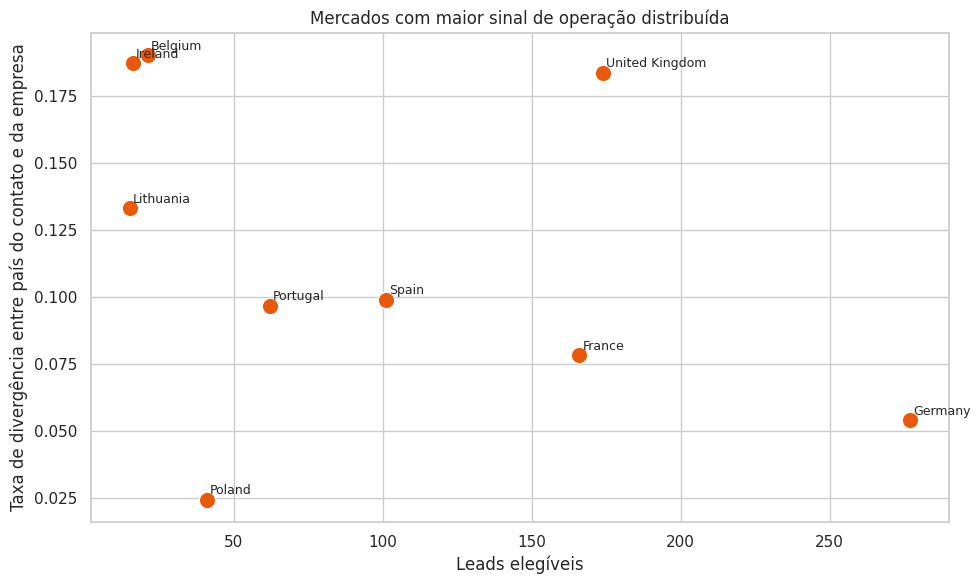

,company_country,lead_count,mismatch_rate
0,Belgium,21,0.19
4,Ireland,16,0.19
12,United Kingdom,174,0.18
6,Lithuania,15,0.13
10,Spain,101,0.10
9,Portugal,62,0.10
2,France,166,0.08
3,Germany,277,0.05
8,Poland,41,0.02


Figura salva em: /home/lucasguldem/dev/data-science/isabellysto-data-analytics/reports/figures/03_cross_border_signal.png


In [6]:
mismatch_df = (
    clean_df.groupby('company_country')
    .agg(
        lead_count=('email', 'count'),
        mismatch_rate=('contact_company_country_mismatch', 'mean'),
    )
    .reset_index()
    .query('lead_count >= 10')
    .sort_values(['mismatch_rate', 'lead_count'], ascending=[False, False])
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=mismatch_df, x='lead_count', y='mismatch_rate', s=140, color='#ea580c', ax=ax)
for _, row in mismatch_df.iterrows():
    ax.text(row['lead_count'] + 1, row['mismatch_rate'] + 0.002, row['company_country'], fontsize=9)
ax.set_title('Mercados com maior sinal de operação distribuída')
ax.set_xlabel('Leads elegíveis')
ax.set_ylabel('Taxa de divergência entre país do contato e da empresa')
plt.tight_layout()
mismatch_figure = FIGURES_DIR / '03_cross_border_signal.png'
plt.savefig(mismatch_figure, dpi=150, bbox_inches='tight')
plt.show()

display(mismatch_df.head(15))
print(f'Figura salva em: {mismatch_figure}')

## 6. Síntese Executiva

O objetivo final é transformar os números em mensagens acionáveis para mercado, ICP e narrativa comercial.

In [7]:
top5 = country_dim.head(5)
top5_share = top5['lead_count'].sum() / len(clean_df)
enterprise_share = (clean_df['company_size_segment'] == '3. Enterprise').mean()
startup_share = (clean_df['company_size_segment'] == '1. Startup / SMB').mean()
mid_market_share = (clean_df['company_size_segment'] == '2. Mid-Market').mean()
cross_border_share = clean_df['contact_company_country_mismatch'].mean()

enterprise_roles = (
    clean_df[clean_df['company_size_segment'] == '3. Enterprise']['role_category']
    .value_counts(normalize=True)
    .head(2)
)
startup_roles = (
    clean_df[clean_df['company_size_segment'] == '1. Startup / SMB']['role_category']
    .value_counts(normalize=True)
    .head(2)
)

summary_lines = [
    f"Os cinco maiores mercados concentram {top5_share:.1%} dos leads elegíveis: {', '.join(top5['company_country'])}.",
    f"Germany lidera em volume absoluto ({int(top5.iloc[0]['lead_count'])} leads), enquanto France e United Kingdom reforçam o eixo de compliance e decisão técnica.",
    f"A base é puxada por empresas enterprise ({enterprise_share:.1%}), mas SMB/startup ({startup_share:.1%}) e mid-market ({mid_market_share:.1%}) juntas representam quase metade do mercado, justificando mensagens comerciais diferentes por porte.",
    f"As personas dominantes são Executive / Technical Decision Maker ({role_dim.iloc[0]['lead_share']:.1%}) e Data / Compliance ({role_dim.iloc[1]['lead_share']:.1%}), o que sugere dupla narrativa: performance técnica para tecnologia e privacidade/compliance para compradores mais regulatórios.",
    f"{cross_border_share:.1%} da base limpa apresenta divergência entre país do contato e país da empresa, sinalizando operações distribuídas onde a hCaptcha pode reforçar cobertura global de borda e proteção consistente entre regiões.",
    f"Em enterprise, a combinação mais forte é {enterprise_roles.index[0]} seguida de {enterprise_roles.index[1]}; em startup/SMB, os papéis mais presentes são {startup_roles.index[0]} e {startup_roles.index[1]}.",
]

for line in summary_lines:
    display(Markdown(f'- {line}'))

report_path = PROJECT_ROOT / 'reports' / 'hcaptcha_positioning_summary.md'
report_text = '# Relatório Executivo: Posicionamento da hCaptcha na Europa\n\n' + '\n'.join(f'- {line}' for line in summary_lines) + '\n'
report_path.write_text(report_text, encoding='utf-8')
print(f'Relatório salvo em: {report_path}')

- Os cinco maiores mercados concentram 88.4% dos leads elegíveis: Germany, United Kingdom, France, Spain, Portugal.

- Germany lidera em volume absoluto (277 leads), enquanto France e United Kingdom reforçam o eixo de compliance e decisão técnica.

- A base é puxada por empresas enterprise (42.7%), mas SMB/startup (29.1%) e mid-market (27.6%) juntas representam quase metade do mercado, justificando mensagens comerciais diferentes por porte.

- As personas dominantes são Executive / Technical Decision Maker (41.3%) e Data / Compliance (36.7%), o que sugere dupla narrativa: performance técnica para tecnologia e privacidade/compliance para compradores mais regulatórios.

- 10.1% da base limpa apresenta divergência entre país do contato e país da empresa, sinalizando operações distribuídas onde a hCaptcha pode reforçar cobertura global de borda e proteção consistente entre regiões.

- Em enterprise, a combinação mais forte é Data / Compliance seguida de Executive / Technical Decision Maker; em startup/SMB, os papéis mais presentes são Executive / Technical Decision Maker e Data / Compliance.

Relatório salvo em: /home/lucasguldem/dev/data-science/isabellysto-data-analytics/reports/hcaptcha_positioning_summary.md


## 7. Blueprint para o Power BI

1. **Market Overview:** mapa ou barras por `company_country`, cards com leads, empresas, países e taxa de operação distribuída.
2. **ICP e Personas:** barras por `role_category`, heatmap `role_category x company_size_segment`, ranking de setores.
3. **Go-to-Market:** matriz de países por porte, tabela de `priority_tier`, scatter de `lead_count x mismatch_rate`.
4. **Executive Summary:** mensagens recomendadas por tier, persona e argumento comercial.